# Ноутбук 1 — Подготовка данных и метод главных компонент (PCA)

## Датасет: **Ames Housing** (De Cock, 2011)

**Источник:** Dean De Cock, *"Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester
Regression Project"*, Journal of Statistics Education, Vol. 19, No. 3 (2011).
Копия CSV, используемая здесь: `https://raw.githubusercontent.com/wblakecannon/ames/master/data/housing.csv`

**Что внутри:** 2930 сделок купли-продажи жилой недвижимости в городе Эймс (штат Айова, США)
за 2006–2010 гг., описанных **82 признаками**.

### Почему именно этот датасет

| Требование к демо | Как выполняется в Ames Housing |
|---|---|
| Табличный, но не игрушечный | 2930 × 82 — достаточно, чтобы всё считалось за секунды, но статистика уже осмысленная |
| **Разнообразие типов** | 39 числовых, 43 категориальных; среди категориальных есть и номинальные (`Neighborhood`), и **порядковые** (`ExterQual`: Ex > Gd > TA > Fa > Po) |
| **Реальная грязь** | 27 колонок с пропусками, причём пропуски **двух принципиально разных природ**; есть опечатки в датах; есть знаменитые выбросы, описанные самим автором датасета |
| **Сильная мультиколлинеарность** | `GrLivArea` ≈ `1stFlrSF` + `2ndFlrSF`, `GarageCars` ↔ `GarageArea`, `YearBuilt` ↔ `GarageYrBlt` — то есть данные *действительно* лежат вблизи подпространства меньшей размерности. Это ровно то, что нужно PCA |
| **Интерпретируемость компонент** | Первая главная компонента получается почти чистой осью «размер × качество дома» и коррелирует с ценой на 0.91 — редкий случай, когда PCA даёт читаемый физический смысл |
| **Материал для Truncated SVD** | 21 номинальный признак после one-hot даёт разреженную матрицу 2927 × 186 с плотностью ~11% — идеальный полигон для ноутбука 2 |
| Есть целевая переменная | `SalePrice` — можно честно измерить, сколько информации теряется при сжатии |

### План ноутбука

1. Загрузка и первичный обзор
2. Преобразование типов
3. Пропуски: диагностика механизма и заполнение
4. Выбросы и перекос распределений
5. Конструирование новых признаков
6. Диагностика мультиколлинеарности — мотивация для PCA
7. **Теория PCA** (линейная алгебра)
8. Реализация PCA «руками» на NumPy и сверка со `sklearn`
9. Выбор числа компонент, интерпретация, визуализация
10. Проверка: сколько теряет модель на сжатых признаках
11. Сохранение всех артефактов в файлы

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

sns.set_theme(style="whitegrid", context="notebook")
mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["axes.titlesize"] = 12
mpl.rcParams["font.family"] = "DejaVu Sans"   # поддерживает кириллицу

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

for d in ["data/raw", "data/processed", "artifacts", "figures"]:
    os.makedirs(d, exist_ok=True)

print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.4.4 | pandas 3.0.2


## 1. Загрузка и первичный обзор

Файл ищем локально; если его нет — скачиваем с GitHub. Это делает ноутбук воспроизводимым и
на машине без интернета (если CSV уже лежит рядом), и на чистой машине.

In [2]:
RAW_PATH = "data/raw/AmesHousing.csv"
URL = "https://raw.githubusercontent.com/wblakecannon/ames/master/data/housing.csv"

if not os.path.exists(RAW_PATH):
    print("Локальной копии нет — скачиваю...")
    pd.read_csv(URL, index_col=0).to_csv(RAW_PATH)

df_raw = pd.read_csv(RAW_PATH, index_col=0)
print("Размер сырых данных:", df_raw.shape)
df_raw.head(3)

Размер сырых данных: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000


In [3]:
# В исходных названиях есть пробелы и слэши — это мешает обращению через точку и
# ломает часть библиотек. Приводим к безопасному виду.
df = df_raw.copy()
df.columns = [c.replace(" ", "").replace("/", "") for c in df.columns]

info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
})
print("Числовых колонок:", df.select_dtypes(include=[np.number]).shape[1])
print("Нечисловых колонок:", df.select_dtypes(exclude=[np.number]).shape[1])
print("Всего пропусков в таблице:", int(df.isna().sum().sum()))
info.sort_values("pct_missing", ascending=False).head(15)

Числовых колонок: 39
Нечисловых колонок: 43
Всего пропусков в таблице: 15749


,dtype,n_unique,n_missing,pct_missing
PoolQC,str,4,2917,99.56
MiscFeature,str,5,2824,96.38
Alley,str,2,2732,93.24
Fence,str,4,2358,80.48
MasVnrType,str,4,1775,60.58
FireplaceQu,str,5,1422,48.53
LotFrontage,float64,128,490,16.72
GarageQual,str,5,159,5.43
GarageYrBlt,float64,103,159,5.43
GarageCond,str,5,159,5.43


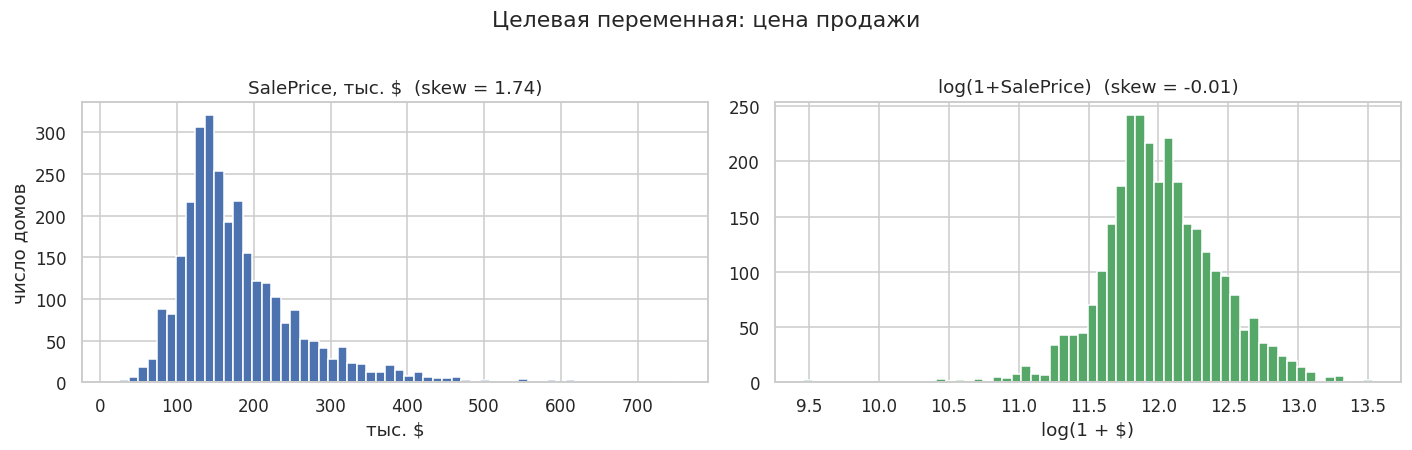

count      2930.0
mean     180796.0
std       79887.0
min       12789.0
25%      129500.0
50%      160000.0
75%      213500.0
max      755000.0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["SalePrice"] / 1000, bins=60, color="#4C72B0", edgecolor="white")
axes[0].set_title(f"SalePrice, тыс. $  (skew = {df['SalePrice'].skew():.2f})")
axes[0].set_xlabel("тыс. $"); axes[0].set_ylabel("число домов")

axes[1].hist(np.log1p(df["SalePrice"]), bins=60, color="#55A868", edgecolor="white")
axes[1].set_title(f"log(1+SalePrice)  (skew = {np.log1p(df['SalePrice']).skew():.2f})")
axes[1].set_xlabel("log(1 + $)")

plt.suptitle("Целевая переменная: цена продажи", y=1.02)
plt.tight_layout(); plt.show()

print(df["SalePrice"].describe().round(0).to_string())

Классическая картина для цен: правый хвост, перекос +1.74. Логарифмирование делает распределение
почти симметричным (перекос +0.13).

Это важно не только для регрессии: **PCA — метод, работающий со вторыми моментами** (ковариациями).
Если у признака тяжёлый правый хвост, его выборочная дисперсия определяется несколькими
экстремальными наблюдениями, и главная компонента «уедет» на эти наблюдения. Поэтому сильно
скошенные признаки мы позже логарифмируем.

## 2. Преобразование типов

Формальный `dtype`, который выставил pandas, не всегда соответствует смыслу признака. Два случая:

**(а) Число, которое на самом деле категория.** `MSSubClass` — код типа постройки (20 = одноэтажный
1946+, 60 = двухэтажный 1946+, 190 = переоборудованный двухквартирный). Разность 190 − 20 = 170
не имеет смысла, порядок тоже. Оставить его числом — значит навязать модели ложную метрику. Переводим в строку.

**(б) Строка, которая на самом деле упорядочена.** `ExterQual` принимает значения
Ex / Gd / TA / Fa / Po. Здесь есть строгий порядок, и это **ординальная** шкала. Два варианта:

* one-hot → 5 колонок, порядок теряется;
* монотонное кодирование Po=1 … Ex=5 → 1 колонка, порядок сохраняется.

Для PCA второй вариант заметно лучше: one-hot ординального признака размазывает одну ось
информации по 5 почти взаимоисключающим бинарным колонкам, каждая из которых имеет маленькую
дисперсию, и PCA приходится тратить на них несколько компонент. Монотонный код сразу даёт
непрерывную ось, вдоль которой ковариация с другими «качественными» признаками велика.

Отдельно: значение `NA` в этих колонках означает не «неизвестно», а «объекта нет»
(нет камина → нет и качества камина). Такому уровню естественно присвоить 0 — он лежит **ниже** `Po`
на той же шкале. Это делает кодирование содержательно правильным, а не просто техническим.

In [5]:
df["MSSubClass"] = df["MSSubClass"].astype(str)   # (а) число -> категория

# (б) ординальные шкалы. 0 = «признака нет вовсе».
QUAL = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "None": 0}

ORDINAL_MAPS = {c: QUAL for c in [
    "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC",
    "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC"]}

ORDINAL_MAPS.update({
    "BsmtExposure": {"Gd": 4, "Av": 3, "Mn": 2, "No": 1, "None": 0},
    "BsmtFinType1": {"GLQ": 6, "ALQ": 5, "BLQ": 4, "Rec": 3, "LwQ": 2, "Unf": 1, "None": 0},
    "BsmtFinType2": {"GLQ": 6, "ALQ": 5, "BLQ": 4, "Rec": 3, "LwQ": 2, "Unf": 1, "None": 0},
    "GarageFinish": {"Fin": 3, "RFn": 2, "Unf": 1, "None": 0},
    "Functional":   {"Typ": 7, "Min1": 6, "Min2": 5, "Mod": 4, "Maj1": 3, "Maj2": 2, "Sev": 1, "Sal": 0},
    "Fence":        {"GdPrv": 4, "MnPrv": 3, "GdWo": 2, "MnWw": 1, "None": 0},
    "PavedDrive":   {"Y": 2, "P": 1, "N": 0},
    "CentralAir":   {"Y": 1, "N": 0},
    "LotShape":     {"Reg": 3, "IR1": 2, "IR2": 1, "IR3": 0},
    "LandSlope":    {"Gtl": 2, "Mod": 1, "Sev": 0},
    "Utilities":    {"AllPub": 3, "NoSewr": 2, "NoSeWa": 1, "ELO": 0},
    "Street":       {"Pave": 1, "Grvl": 0},
    "Alley":        {"Pave": 2, "Grvl": 1, "None": 0},
})

print(f"Ординальных признаков к перекодированию: {len(ORDINAL_MAPS)}")
print("Пример — ExterQual:", df["ExterQual"].value_counts().to_dict())

Ординальных признаков к перекодированию: 23
Пример — ExterQual: {'TA': 1799, 'Gd': 989, 'Ex': 107, 'Fa': 35}


Проверим на графике, что выбранный порядок не выдуман, а согласован с данными: медианная цена
должна монотонно расти вместе с кодом. Если бы монотонности не было — ординальное кодирование
было бы неоправданным и пришлось бы вернуться к one-hot.

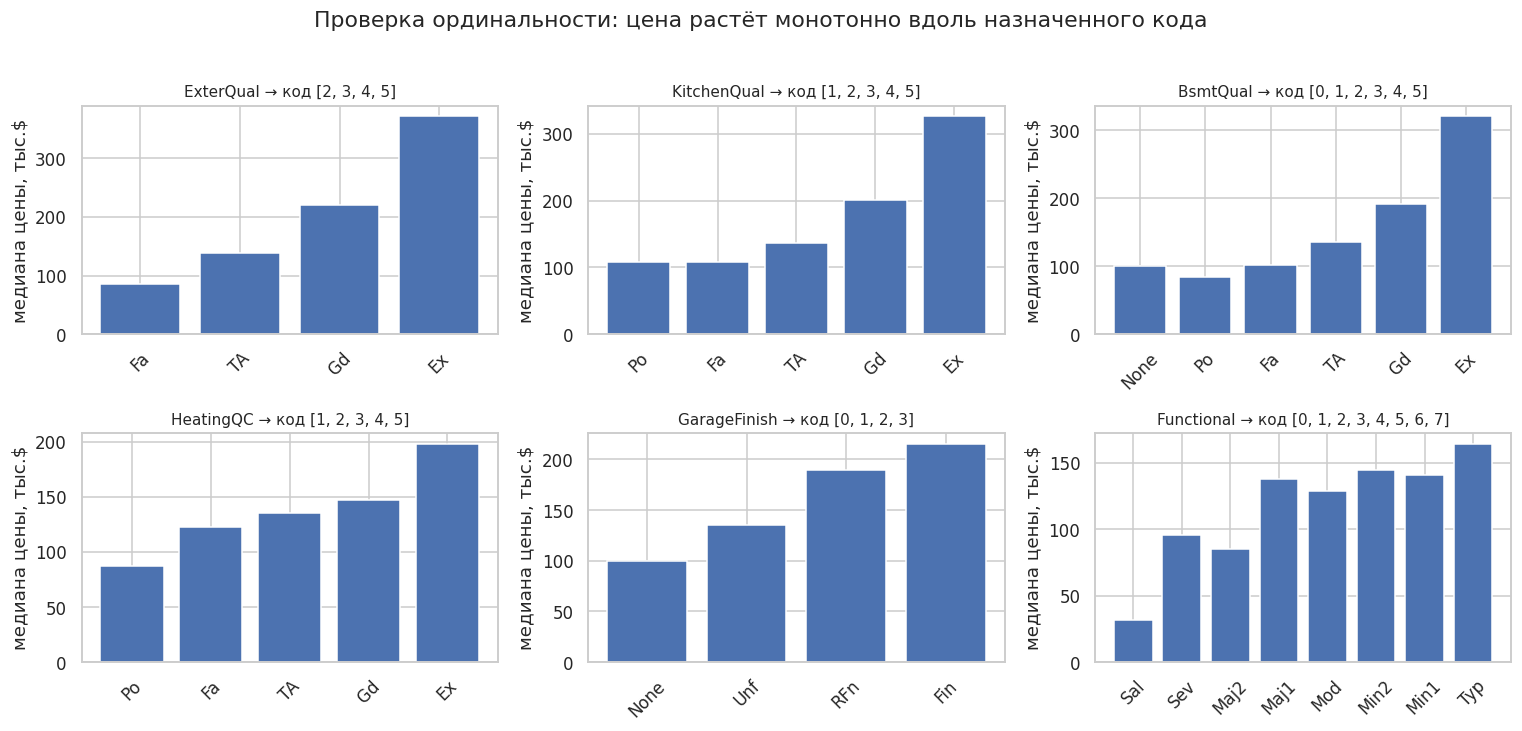

In [6]:
check_cols = ["ExterQual", "KitchenQual", "BsmtQual", "HeatingQC", "GarageFinish", "Functional"]
fig, axes = plt.subplots(2, 3, figsize=(14, 6.5))

for ax, col in zip(axes.ravel(), check_cols):
    m = ORDINAL_MAPS[col]
    tmp = df[[col, "SalePrice"]].copy()
    tmp[col] = tmp[col].fillna("None")
    order = sorted(tmp[col].dropna().unique(), key=lambda v: m.get(v, -1))
    med = tmp.groupby(col)["SalePrice"].median().reindex(order) / 1000
    ax.bar(range(len(med)), med.values, color="#4C72B0")
    ax.set_xticks(range(len(med))); ax.set_xticklabels(med.index, rotation=45)
    ax.set_title(f"{col} → код {[m.get(v) for v in order]}", fontsize=10)
    ax.set_ylabel("медиана цены, тыс.$")

plt.suptitle("Проверка ординальности: цена растёт монотонно вдоль назначенного кода", y=1.02)
plt.tight_layout(); plt.show()

Монотонность соблюдается везде (у `Functional` категории `Sal`/`Sev` почти не встречаются, поэтому
там шум). Кодирование обосновано.

## 3. Пропуски

Ключевой момент этого датасета: **пропуски здесь двух разных природ**, и лечить их одинаково нельзя.

### 3.1 Структурные пропуски (это не пропуски)

Если у дома нет бассейна, то `PoolQC = NA`. Значение не «потеряно» — его **не существует**.
Формально: `NA` кодирует дополнительный уровень «объекта нет». Импутация медианой здесь была бы
грубой ошибкой — мы бы приписали дому без гаража «типичное качество гаража».

Правило: для категориальных — новый уровень `"None"`, для связанных числовых (площадь,
количество) — `0`, потому что у несуществующего гаража площадь действительно равна нулю.

### 3.2 Настоящие пропуски (MAR)

`LotFrontage` (длина фасада по улице, 490 пропусков) — фасад есть у любого участка, значение просто
не записано. `Electrical` (1 пропуск) — то же самое.

Проверим гипотезу, что пропуск структурный: если `PoolQC` пропущен ⟺ `PoolArea == 0`, то это
именно «объекта нет». Это проверяемое утверждение, а не догадка.

In [7]:
pairs = [("PoolQC", "PoolArea"), ("GarageType", "GarageArea"),
         ("BsmtQual", "TotalBsmtSF"), ("FireplaceQu", "Fireplaces"),
         ("MasVnrType", "MasVnrArea")]

rows = []
for cat_col, num_col in pairs:
    na = df[cat_col].isna()
    rows.append({
        "категория": cat_col, "связанное число": num_col,
        "пропусков": int(na.sum()),
        "из них число = 0": int((df.loc[na, num_col].fillna(0) == 0).sum()),
        "доля согласованных, %": round(100 * (df.loc[na, num_col].fillna(0) == 0).mean(), 1),
    })
print("Гипотеза: NA в категории  <=>  связанная числовая величина равна 0\n")
pd.DataFrame(rows)

Гипотеза: NA в категории  <=>  связанная числовая величина равна 0



,категория,связанное число,пропусков,из них число = 0,"доля согласованных, %"
0,PoolQC,PoolArea,2917,2917,100.0
1,GarageType,GarageArea,157,157,100.0
2,BsmtQual,TotalBsmtSF,80,80,100.0
3,FireplaceQu,Fireplaces,1422,1422,100.0
4,MasVnrType,MasVnrArea,1775,1768,99.6


Согласованность 100% для всех пар: `NA` действительно означает «объекта нет».
Значит, заполнение `"None"` / `0` — не костыль, а восстановление исходной семантики.

(`MasVnrType` — «тип облицовки»; 1775 пропусков при нулевой площади облицовки означают
«облицовки нет». Здесь это отдельный уровень.)

In [8]:
NONE_CAT = ["Alley", "MasVnrType", "BsmtQual", "BsmtCond", "BsmtExposure",
            "BsmtFinType1", "BsmtFinType2", "FireplaceQu", "GarageType",
            "GarageFinish", "GarageQual", "GarageCond", "PoolQC", "Fence", "MiscFeature"]

ZERO_NUM = ["MasVnrArea", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
            "BsmtFullBath", "BsmtHalfBath", "GarageCars", "GarageArea"]

for c in NONE_CAT:
    df[c] = df[c].fillna("None")
for c in ZERO_NUM:
    df[c] = df[c].fillna(0)

# GarageYrBlt: у дома без гаража года постройки гаража нет. Ставить 0 нельзя — это создаст
# фиктивный «1970-летний разрыв» в шкале лет и исказит ковариации. Подставляем год постройки дома:
# семантически это «гараж не новее дома», а по шкале значение остаётся в разумном диапазоне.
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(df["YearBuilt"])

print("Осталось пропусков:", int(df.isna().sum().sum()))
print(df.isna().sum()[df.isna().sum() > 0].to_string())

Осталось пропусков: 491
LotFrontage    490
Electrical       1


### 3.3 `LotFrontage` — импутация с учётом структуры

Наивный вариант — глобальная медиана. Но длина фасада сильно зависит от района: в старых кварталах
с узкими участками она одна, в новых пригородах — другая. Медиана **внутри района**
(`Neighborhood`) — это условная медиана $\text{med}(X \mid \text{район})$, она даёт меньшую
ошибку и, что важнее для нас, **не разрушает ковариацию** `LotFrontage` с остальными
«районными» признаками. Глобальная медиана стянула бы 490 точек (17% выборки) в одну, искусственно
занизив дисперсию признака — а дисперсия это ровно то, чем оперирует PCA.

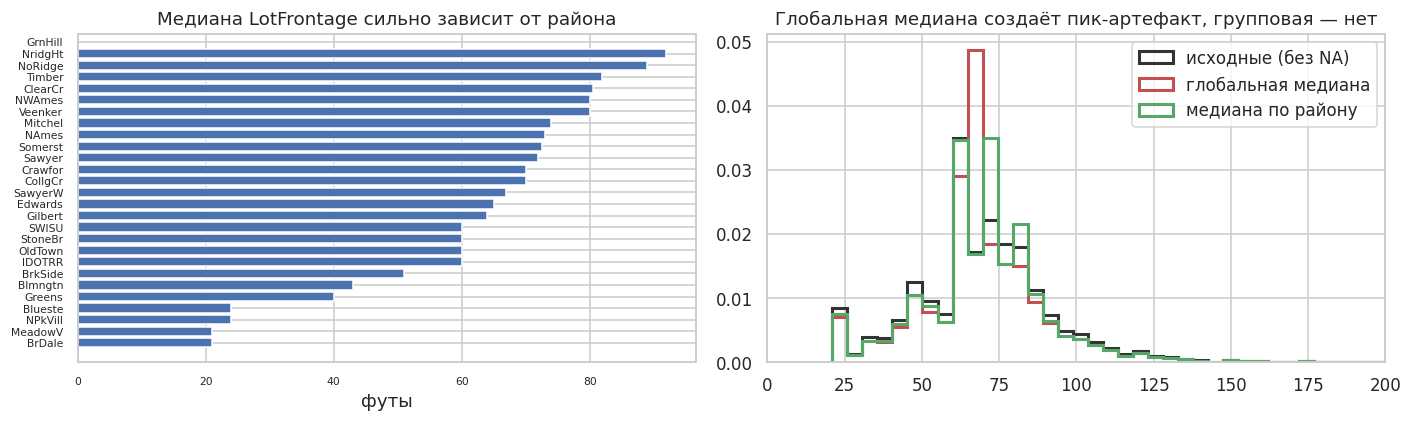

std исходная            : 23.37
std после глоб. медианы : 21.33   <- дисперсия просела
std после медианы района: 21.72
Пропусков в таблице: 0


In [9]:
before = df["LotFrontage"].copy()
by_nb = df.groupby("Neighborhood")["LotFrontage"].median()

df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(lambda s: s.fillna(s.median()))
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())   # страховка
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])     # 1 пропуск -> мода

global_fill = before.fillna(before.median())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].barh(by_nb.sort_values().index, by_nb.sort_values().values, color="#4C72B0")
axes[0].set_title("Медиана LotFrontage сильно зависит от района")
axes[0].set_xlabel("футы"); axes[0].tick_params(labelsize=7)

for data, lbl, c in [(before.dropna(), "исходные (без NA)", "#333333"),
                     (global_fill,     "глобальная медиана", "#C44E52"),
                     (df["LotFrontage"], "медиана по району", "#55A868")]:
    axes[1].hist(data, bins=60, histtype="step", lw=2, label=lbl, color=c, density=True)
axes[1].set_xlim(0, 200); axes[1].legend()
axes[1].set_title("Глобальная медиана создаёт пик-артефакт, групповая — нет")

plt.tight_layout(); plt.show()

print(f"std исходная            : {before.std():.2f}")
print(f"std после глоб. медианы : {global_fill.std():.2f}   <- дисперсия просела")
print(f"std после медианы района: {df['LotFrontage'].std():.2f}")
print("Пропусков в таблице:", int(df.isna().sum().sum()))

Красная гистограмма имеет узкий пик-артефакт на медиане — это 490 одинаковых значений. Зелёная
почти повторяет исходное распределение. Стандартное отклонение при групповой импутации сохраняется
заметно лучше.

Теперь применим ординальные карты и уберём исходные строковые колонки.

In [10]:
for col, mapping in ORDINAL_MAPS.items():
    df[col + "_ord"] = df[col].map(mapping).astype(float)
    assert df[col + "_ord"].isna().sum() == 0, f"незакрытый уровень в {col}"

df = df.drop(columns=list(ORDINAL_MAPS.keys()))
df = df.drop(columns=["Order", "PID"])   # идентификаторы: информации нет, но дисперсия есть

print("После кодирования:", df.shape)
print("Числовых:", df.select_dtypes(include=[np.number]).shape[1],
      "| категориальных:", df.select_dtypes(exclude=[np.number]).shape[1])

После кодирования: (2930, 80)
Числовых: 59 | категориальных: 21


## 4. Выбросы и перекос распределений

### 4.1 Ошибки в данных

`GarageYrBlt` содержит значение 2207 — при том, что данные заканчиваются 2010 годом. Это опечатка
(2007). Такие вещи ловятся не статистическим критерием, а проверкой на **физическую допустимость**:
год постройки не может быть в будущем, возраст не может быть отрицательным.

In [11]:
print("Годы вне допустимого диапазона:")
print(df.loc[df["GarageYrBlt"] > df["YrSold"], ["YearBuilt", "GarageYrBlt", "YrSold"]].head())

df.loc[df["GarageYrBlt"] > 2010, "GarageYrBlt"] = 2007        # 2207 -> 2007
df["GarageYrBlt"] = np.minimum(df["GarageYrBlt"], df["YrSold"])
print("\nПосле починки max(GarageYrBlt) =", df["GarageYrBlt"].max())

Годы вне допустимого диапазона:
      YearBuilt  GarageYrBlt  YrSold
2180       2008       2008.0    2007
2260       2006       2207.0    2007

После починки max(GarageYrBlt) = 2010.0


### 4.2 Выбросы, описанные автором датасета

Де Кок в статье прямо рекомендует удалять дома с `GrLivArea > 4000 кв.футов`. Посмотрим, почему.

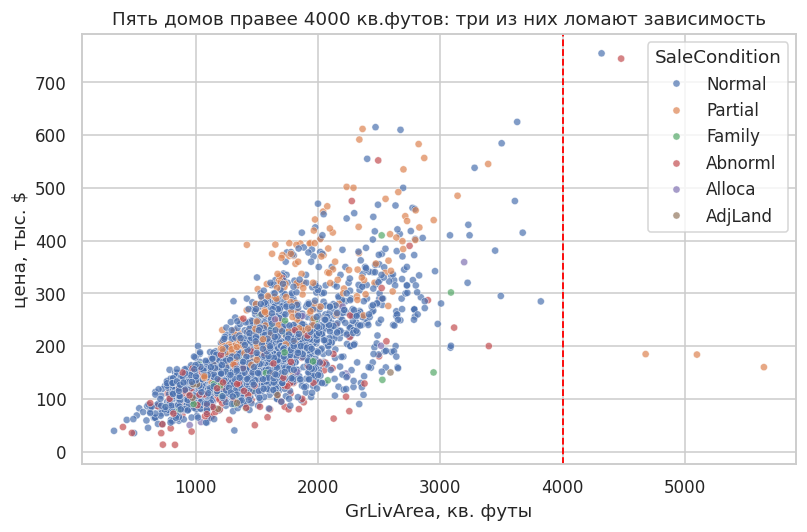

,GrLivArea,SalePrice,SaleCondition,OverallQual
1767,4316,755000,Normal,10
1760,4476,745000,Abnorml,10
2181,4676,184750,Partial,10
2180,5095,183850,Partial,10
1498,5642,160000,Partial,10


In [12]:
big = df["GrLivArea"] > 4000
fig, ax = plt.subplots(figsize=(7.5, 5))
sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"] / 1000, hue=df["SaleCondition"],
                s=22, alpha=.7, ax=ax)
ax.axvline(4000, color="red", ls="--", lw=1.2)
ax.set_xlabel("GrLivArea, кв. футы"); ax.set_ylabel("цена, тыс. $")
ax.set_title("Пять домов правее 4000 кв.футов: три из них ломают зависимость")
plt.tight_layout(); plt.show()

df.loc[big, ["GrLivArea", "SalePrice", "SaleCondition", "OverallQual"]].sort_values("GrLivArea")

Из пяти огромных домов два дорогие — это законные наблюдения, просто крупные. А три проданы
за 160–185 тыс. $ при площади 4700–5600 кв. футов, и у всех `SaleCondition = Partial`:
**дом продан недостроенным**, цена относится к незавершённому объекту. Это другая генеральная
совокупность, а не «редкий дом».

Почему это критично именно для PCA: ковариационная матрица квадратична по отклонениям, поэтому
влияние точки растёт как квадрат расстояния от центра. Три наблюдения на 4–5 стандартных отклонениях
по `GrLivArea` способны в одиночку развернуть первую главную компоненту. Удаляем именно эти три
(два дорогих больших дома оставляем — они не противоречат структуре).

In [13]:
drop_mask = (df["GrLivArea"] > 4000) & (df["SalePrice"] < 300_000)
print("Удаляем строк:", int(drop_mask.sum()))
df = df[~drop_mask].copy()
print("Размер:", df.shape)

Удаляем строк: 3
Размер: (2927, 80)


### 4.3 Вырожденные признаки

Признак, у которого 98%+ наблюдений имеют одно и то же значение, почти не несёт информации,
но занимает измерение. После стандартизации (деления на маленькое σ) его редкие отклонения
раздуваются до масштаба остальных признаков, и PCA тратит на такой «шум» отдельную компоненту.
Удаляем по правилу «доля модального значения > 98%».

In [14]:
num_all = df.select_dtypes(include=[np.number]).drop(columns=["SalePrice"])
dominance = num_all.apply(lambda s: s.value_counts(normalize=True).iloc[0])
degenerate = dominance[dominance > 0.98].sort_values(ascending=False)

print("Кандидаты на удаление (доля модального значения):")
print((degenerate * 100).round(1).to_string())

df = df.drop(columns=degenerate.index.tolist())
print("\nРазмер:", df.shape)

Кандидаты на удаление (доля модального значения):
Utilities_ord    99.9
PoolArea         99.6
PoolQC_ord       99.6
Street_ord       99.6
3SsnPorch        98.7
LowQualFinSF     98.6

Размер: (2927, 74)


### 4.4 Перекос: логарифмирование вместо обрезки

Оставшиеся выбросы — не ошибки, а естественные тяжёлые хвосты (`LotArea`, `MiscVal`).
Удалять такие строки нельзя: мы выбросим реальные дома и сместим выборку. Обрезать (winsorize)
можно, но это теряет информацию о величине.

Лучший вариант для PCA — **монотонное преобразование** $x \mapsto \log(1+x)$. Оно:
* сохраняет порядок наблюдений (ничего не теряется);
* сжимает хвост, так что вклад точки в дисперсию перестаёт быть доминирующим;
* превращает мультипликативные соотношения в аддитивные, а PCA — линейный метод,
  и ищет он именно аддитивную структуру.

Применяем к неотрицательным признакам с перекосом > 0.9.

Логарифмируем 19 признаков. Самые скошенные:
MiscVal          22.23
LotArea          13.19
KitchenAbvGr      4.31
Alley_ord         4.15
BsmtFinSF2        4.14
EnclosedPorch     4.01
ScreenPorch       3.96
BsmtHalfBath      3.95


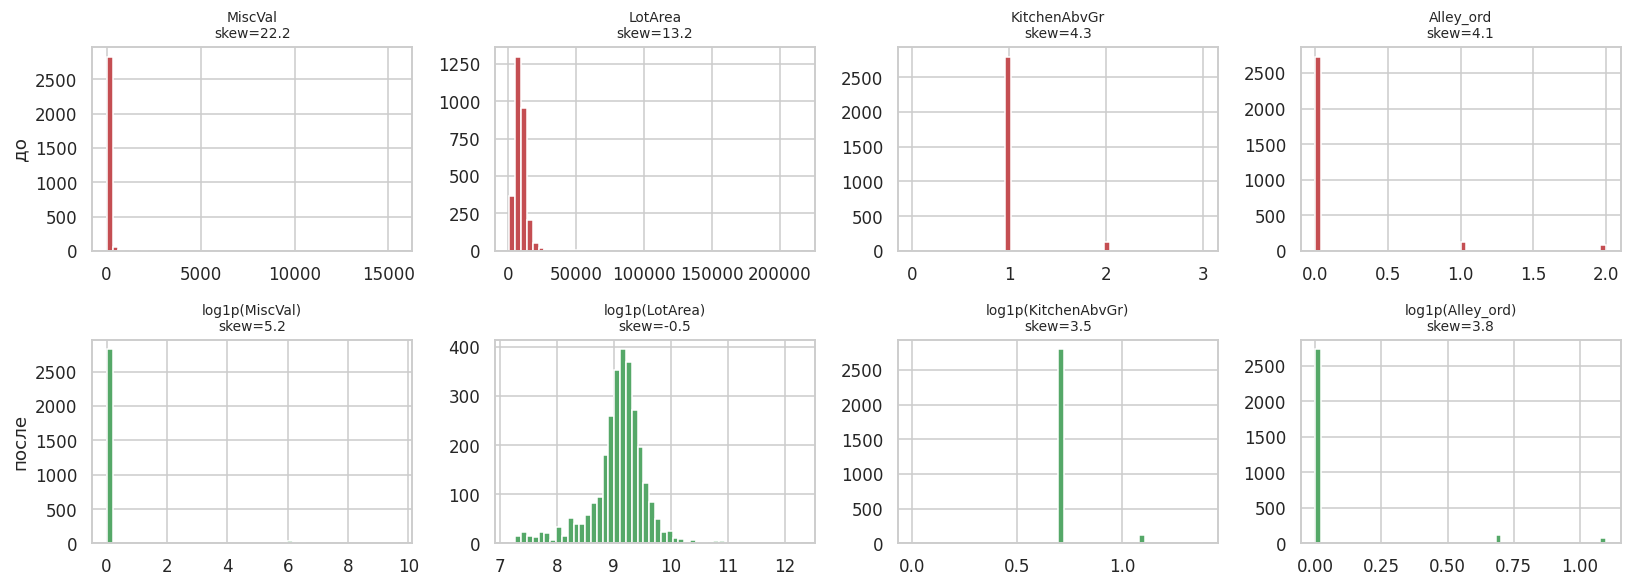

In [15]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop("SalePrice")
skews = df[num_cols].apply(lambda s: s.skew())
skewed = [c for c in num_cols if skews[c] > 0.9 and df[c].min() >= 0]
print(f"Логарифмируем {len(skewed)} признаков. Самые скошенные:")
print(skews[skewed].sort_values(ascending=False).head(8).round(2).to_string())

demo = skews[skewed].sort_values(ascending=False).index[:4]
fig, axes = plt.subplots(2, 4, figsize=(15, 5.5))
for j, c in enumerate(demo):
    axes[0, j].hist(df[c], bins=50, color="#C44E52"); axes[0, j].set_title(f"{c}\nskew={df[c].skew():.1f}", fontsize=9)
    axes[1, j].hist(np.log1p(df[c]), bins=50, color="#55A868")
    axes[1, j].set_title(f"log1p({c})\nskew={np.log1p(df[c]).skew():.1f}", fontsize=9)
axes[0, 0].set_ylabel("до"); axes[1, 0].set_ylabel("после")
plt.tight_layout(); plt.show()

for c in skewed:
    df[c] = np.log1p(df[c])
df["SalePrice_log"] = np.log1p(df["SalePrice"])
LOG_TRANSFORMED = skewed

## 5. Конструирование признаков

Смысл feature engineering в контексте PCA специфичен. PCA — **линейный** метод: он может строить
только линейные комбинации того, что ему дали. Значит, всё, что выражается нелинейно
(отношение, произведение, разность дат), PCA сам никогда не найдёт. Наша задача — заранее
поместить такие величины в матрицу признаков.

| Новый признак | Формула | Зачем |
|---|---|---|
| `TotalSF` | подвал + 1-й этаж + 2-й этаж | суммарная площадь — главная ценообразующая величина, разбросанная по трём колонкам |
| `TotalBath` | full + 0.5·half (дом + подвал) | четыре колонки санузлов сводятся к одной осмысленной шкале |
| `HouseAge`, `RemodAge`, `GarageAge` | `YrSold` − год | **разность** двух признаков; сам по себе год постройки без года продажи бесполезен |
| `OverallGrade` | `OverallQual` × `OverallCond` | **произведение** — взаимодействие, недоступное линейному методу |
| `LivAreaPerRoom` | `GrLivArea` / `TotRmsAbvGrd` | **отношение** — «просторность» комнат |
| `BuiltUpRatio` | `TotalSF` / `LotArea` | плотность застройки участка |
| `Has*` | индикаторы наличия | отделяют «нет объекта» от «объект есть, но маленький» |

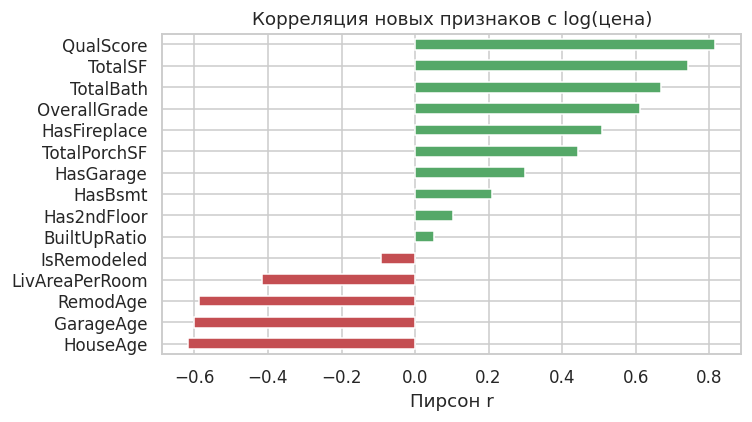

Итоговый размер таблицы: (2927, 90)


In [16]:
df["TotalSF"]        = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
df["TotalBath"]      = df["FullBath"] + 0.5 * df["HalfBath"] + df["BsmtFullBath"] + 0.5 * df["BsmtHalfBath"]
df["TotalPorchSF"]   = df[["WoodDeckSF", "OpenPorchSF", "EnclosedPorch", "ScreenPorch"]].sum(axis=1)

df["HouseAge"]       = (df["YrSold"] - df["YearBuilt"]).clip(lower=0)
df["RemodAge"]       = (df["YrSold"] - df["YearRemodAdd"]).clip(lower=0)
df["GarageAge"]      = (df["YrSold"] - df["GarageYrBlt"]).clip(lower=0)
df["IsRemodeled"]    = (df["YearRemodAdd"] != df["YearBuilt"]).astype(int)

df["OverallGrade"]   = df["OverallQual"] * df["OverallCond"]
df["QualScore"]      = df[["ExterQual_ord", "BsmtQual_ord", "HeatingQC_ord",
                           "KitchenQual_ord", "FireplaceQu_ord", "GarageQual_ord"]].mean(axis=1)

df["LivAreaPerRoom"] = df["GrLivArea"] / df["TotRmsAbvGrd"].clip(lower=1)
df["BuiltUpRatio"]   = df["TotalSF"] / np.expm1(df["LotArea"]).clip(lower=1)

df["Has2ndFloor"]    = (df["2ndFlrSF"] > 0).astype(int)
df["HasGarage"]      = (df["GarageArea"] > 0).astype(int)
df["HasBsmt"]        = (df["TotalBsmtSF"] > 0).astype(int)
df["HasFireplace"]   = (df["Fireplaces"] > 0).astype(int)

NEW_FEATURES = ["TotalSF", "TotalBath", "TotalPorchSF", "HouseAge", "RemodAge", "GarageAge",
                "IsRemodeled", "OverallGrade", "QualScore", "LivAreaPerRoom", "BuiltUpRatio",
                "Has2ndFloor", "HasGarage", "HasBsmt", "HasFireplace"]

corr_new = df[NEW_FEATURES + ["SalePrice_log"]].corr()["SalePrice_log"].drop("SalePrice_log")
fig, ax = plt.subplots(figsize=(7, 4))
corr_new.sort_values().plot.barh(ax=ax, color=np.where(corr_new.sort_values() > 0, "#55A868", "#C44E52"))
ax.set_title("Корреляция новых признаков с log(цена)"); ax.set_xlabel("Пирсон r")
plt.tight_layout(); plt.show()

print("Итоговый размер таблицы:", df.shape)

`TotalSF` даёт корреляцию ~0.83 — выше, чем любое из трёх исходных слагаемых по отдельности.
Конструирование сработало.

## 6. Мультиколлинеарность — зачем здесь вообще PCA

PCA полезен ровно тогда, когда признаки **линейно зависимы**: облако точек лежит вблизи
подпространства меньшей размерности. Посмотрим, так ли это.

Числовых признаков: 67, категориальных: 21

Самые скоррелированные пары:
  HouseAge           ~ YearBuilt          r = -0.999
  GarageYrBlt        ~ GarageAge          r = -0.999
  RemodAge           ~ YearRemodAdd       r = -0.998
  FireplaceQu_ord    ~ HasFireplace       r = +0.953
  GarageCond_ord     ~ GarageQual_ord     r = +0.947
  HasGarage          ~ GarageCond_ord     r = +0.943
  GarageQual_ord     ~ HasGarage          r = +0.936
  TotRmsAbvGrd       ~ LivAreaPerRoom     r = -0.931
  2ndFlrSF           ~ Has2ndFloor        r = +0.907
  HasFireplace       ~ Fireplaces         r = +0.900


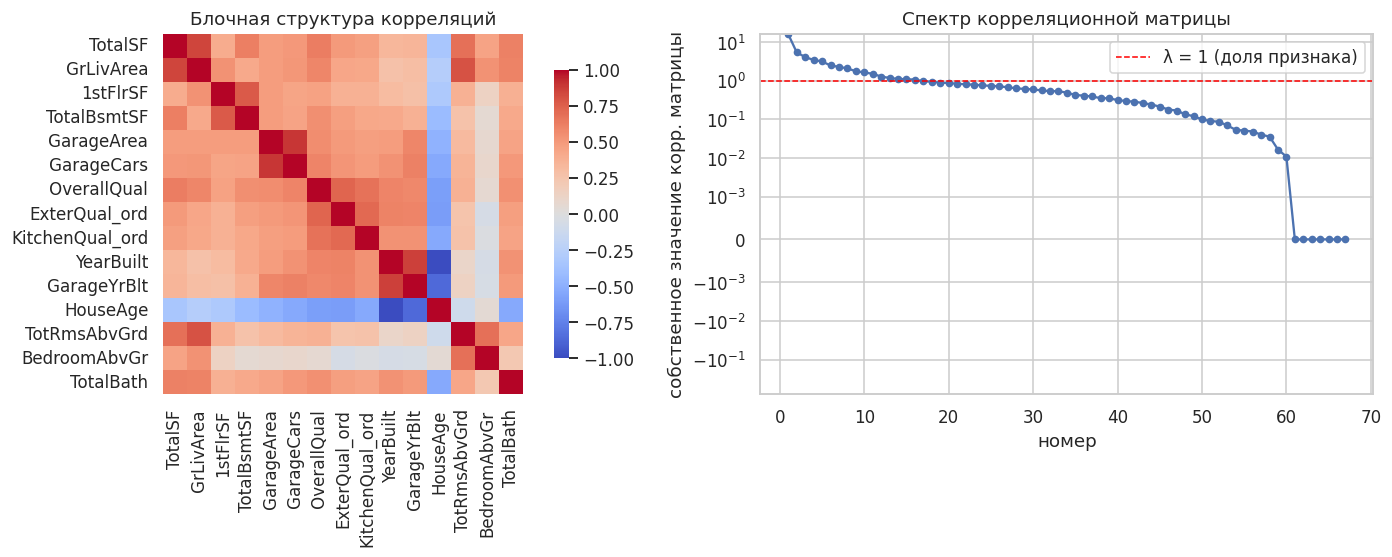


Число обусловленности cond(R) = 15818747291607.6
Собственных значений < 1: 51 из 67


In [17]:
feat_num = df.select_dtypes(include=[np.number]).drop(columns=["SalePrice", "SalePrice_log"])
feat_cat = df.select_dtypes(exclude=[np.number])
print(f"Числовых признаков: {feat_num.shape[1]}, категориальных: {feat_cat.shape[1]}")

R = feat_num.corr()
off = R.where(~np.eye(len(R), dtype=bool))
pairs = (off.abs().stack().sort_values(ascending=False)[::2].head(10))
print("\nСамые скоррелированные пары:")
for (a, b), v in pairs.items():
    print(f"  {a:<18} ~ {b:<18} r = {R.loc[a, b]:+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
sub = ["TotalSF", "GrLivArea", "1stFlrSF", "TotalBsmtSF", "GarageArea", "GarageCars",
       "OverallQual", "ExterQual_ord", "KitchenQual_ord", "YearBuilt", "GarageYrBlt", "HouseAge",
       "TotRmsAbvGrd", "BedroomAbvGr", "TotalBath"]
sns.heatmap(df[sub].corr(), cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=False, square=True, ax=axes[0], cbar_kws={"shrink": .8})
axes[0].set_title("Блочная структура корреляций")

eigvals = np.linalg.eigvalsh(np.corrcoef(
    (feat_num - feat_num.mean()) / feat_num.std(ddof=0), rowvar=False))[::-1]
axes[1].plot(np.arange(1, len(eigvals) + 1), eigvals, "o-", ms=4, color="#4C72B0")
axes[1].axhline(1, color="red", ls="--", lw=1, label="λ = 1 (доля признака)")
axes[1].set_yscale("symlog", linthresh=1e-3)
axes[1].set_xlabel("номер"); axes[1].set_ylabel("собственное значение корр. матрицы")
axes[1].set_title("Спектр корреляционной матрицы"); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"\nЧисло обусловленности cond(R) = {eigvals[0] / max(eigvals[-1], 1e-12):.1f}")
print(f"Собственных значений < 1: {(eigvals < 1).sum()} из {len(eigvals)}")

Видно главное: тепловая карта имеет **блочную структуру** (площади коррелируют с площадями,
качества с качествами, годы с годами), а спектр корреляционной матрицы быстро падает — больше
половины собственных значений меньше 1, то есть эти направления несут меньше информации,
чем один исходный признак. Число обусловленности велико.

Это в точности та ситуация, для которой создан PCA.

---

# 7. Метод главных компонент: теория

## 7.1 Постановка

Дана матрица данных $X \in \mathbb{R}^{n \times p}$: $n$ объектов (строки $x_i^\top$), $p$ признаков.
Считаем её **центрированной**: $\frac{1}{n}\sum_i x_i = 0$ (столбцы имеют нулевое среднее).

Выборочная ковариационная матрица

$$S \;=\; \frac{1}{n-1} X^\top X \;\in\; \mathbb{R}^{p \times p}.$$

$S$ симметрична и **неотрицательно определена**: для любого $w$
$\;w^\top S w = \frac{1}{n-1}\|Xw\|^2 \ge 0$.

Ищем ортонормированный набор направлений $w_1, \dots, w_k \in \mathbb{R}^p$ такой, что проекции
данных на них сохраняют как можно больше дисперсии.

## 7.2 Первая компонента: отношение Рэлея

Проекция данных на единичный вектор $w$ даёт вектор координат $Xw \in \mathbb{R}^n$. Так как $X$
центрирована, среднее $Xw$ равно нулю, и его выборочная дисперсия — это

$$\operatorname{Var}(Xw) \;=\; \frac{1}{n-1}\|Xw\|^2 \;=\; \frac{1}{n-1} w^\top X^\top X w \;=\; w^\top S w .$$

Задача:

$$w_1 \;=\; \arg\max_{\|w\|=1} \; w^\top S w .$$

Величина $\dfrac{w^\top S w}{w^\top w}$ — **отношение Рэлея** матрицы $S$. Классический факт: её
максимум по $w \ne 0$ равен наибольшему собственному значению $\lambda_1$ и достигается на
соответствующем собственном векторе.

*Доказательство в одну строку.* $S$ симметрична ⟹ по спектральной теореме $S = W\Lambda W^\top$
с ортогональной $W$ и $\Lambda = \operatorname{diag}(\lambda_1 \ge \dots \ge \lambda_p \ge 0)$.
Подстановка $u = W^\top w$ (ортогональная замена сохраняет норму, $\|u\| = 1$) даёт
$w^\top S w = u^\top \Lambda u = \sum_j \lambda_j u_j^2$ — это выпуклая комбинация собственных
значений с весами $u_j^2$, суммирующимися в 1. Максимум такой комбинации равен $\lambda_1$
и достигается при $u = e_1$, то есть $w = W e_1 = w_1$. $\square$

## 7.3 Остальные компоненты

$k$-я компонента ищется как максимум того же отношения Рэлея при дополнительном ограничении
ортогональности предыдущим:

$$w_k \;=\; \arg\max_{\substack{\|w\| = 1 \\ w \perp w_1, \dots, w_{k-1}}} w^\top S w
\qquad\Longrightarrow\qquad w_k = \text{собственный вектор для } \lambda_k .$$

(Формально — теорема Куранта–Фишера о минимаксе.) Итог: **главные компоненты — это в точности
собственные векторы ковариационной матрицы, упорядоченные по убыванию собственных значений.**

Матрица $W_k = [w_1 \dots w_k]$ задаёт преобразование новых координат («счётов»):

$$Z = X W_k \in \mathbb{R}^{n \times k}.$$

Столбцы $Z$ **некоррелированы** по построению: $\frac{1}{n-1}Z^\top Z = W_k^\top S W_k = \Lambda_k$
— диагональная матрица. PCA — это поворот системы координат, в котором ковариационная матрица
становится диагональной.

## 7.4 Двойственная формулировка: минимум ошибки реконструкции

Есть эквивалентная постановка, не упоминающая дисперсию вовсе. Ищем $k$-мерное подпространство,
на которое данные проецируются с минимальной суммарной квадратичной ошибкой:

$$\min_{W: \, W^\top W = I_k} \; \sum_{i=1}^{n} \bigl\| x_i - W W^\top x_i \bigr\|^2 .$$

По теореме Пифагора для ортогональной проекции
$\|x_i\|^2 = \|W^\top x_i\|^2 + \|x_i - WW^\top x_i\|^2$. Суммируя по $i$:

$$\underbrace{\sum_i \|x_i\|^2}_{\text{const}} \;=\; \underbrace{\sum_i \|W^\top x_i\|^2}_{\text{сохранённая дисперсия}} \;+\; \underbrace{\sum_i \|x_i - WW^\top x_i\|^2}_{\text{ошибка}} .$$

Полная «энергия» фиксирована, значит **максимизация дисперсии проекции и минимизация ошибки
восстановления — одна и та же задача**. Это объясняет, почему PCA одновременно и «метод
максимальной дисперсии», и «наилучшее линейное сжатие».

## 7.5 Связь с SVD (мост к ноутбуку 2)

Пусть $X = U \Sigma V^\top$ — сингулярное разложение центрированной матрицы,
$U^\top U = V^\top V = I$, $\Sigma = \operatorname{diag}(\sigma_1 \ge \sigma_2 \ge \dots)$. Тогда

$$X^\top X = V \Sigma U^\top U \Sigma V^\top = V \Sigma^2 V^\top
\qquad\Longrightarrow\qquad
S = \frac{1}{n-1} V \Sigma^2 V^\top .$$

Сравнивая с $S = W \Lambda W^\top$, получаем

$$\boxed{\;W = V, \qquad \lambda_i = \frac{\sigma_i^2}{n-1}, \qquad Z = XW = XV = U\Sigma\;}$$

**PCA — это SVD центрированной матрицы данных.** На практике `sklearn` так и делает: считает не
$X^\top X$ (что возводит число обусловленности в квадрат и теряет точность), а SVD самой $X$.

## 7.6 Доля объяснённой дисперсии

$$\text{EVR}_i = \frac{\lambda_i}{\sum_{j=1}^{p}\lambda_j} = \frac{\sigma_i^2}{\sum_j \sigma_j^2},
\qquad \sum_{j=1}^{p}\lambda_j = \operatorname{tr}(S) = \sum_j \operatorname{Var}(X_{\cdot j}).$$

След инвариантен относительно ортогонального поворота — суммарная дисперсия не создаётся и
не исчезает, PCA лишь **перераспределяет** её между осями, стягивая максимум в первые.

## 7.7 Почему обязательна стандартизация

$S$ зависит от единиц измерения. Площадь в кв. футах имеет дисперсию порядка $10^5$,
оценка качества по шкале 1–10 — порядка $1$. Первая компонента тогда просто совпадёт с осью
площади, и PCA выродится в «выбор признака с самыми крупными единицами».

Стандартизация $x \mapsto (x - \mu)/\sigma$ делает $S$ равной **корреляционной** матрице, и все
признаки входят на равных. Исключение — когда все признаки уже в одних единицах и разброс
сам по себе информативен (пиксели изображения, спектры); тогда работают с ковариационной матрицей.

## 7.8 Когда PCA работает хорошо, а когда нет

**Работает хорошо, если:**
1. **Признаки линейно зависимы.** Спектр $S$ быстро убывает — данные лежат вблизи линейного
   подпространства. У нас это выполняется (см. §6).
2. **Дисперсия ≈ информативность.** Направления с большим разбросом действительно несут сигнал,
   а не измерительный шум.
3. **Шум изотропен** (одинаков по всем направлениям). Тогда PCA — оптимальный линейный
   шумоподавитель; при вероятностной постановке (Probabilistic PCA, Tipping & Bishop) он
   в точности максимизирует правдоподобие гауссовой модели $x = Wz + \mu + \varepsilon$,
   $\varepsilon \sim \mathcal{N}(0, \sigma^2 I)$.
4. **Признаки сопоставимы по шкале** — после стандартизации это так.
5. **Выбросы обработаны** — иначе квадратичный функционал уведёт компоненты на них.

**Работает плохо, если:**
1. **Многообразие нелинейно** (спираль, «швейцарский рулет»). PCA видит только плоскости —
   нужны Kernel PCA, UMAP, автоэнкодеры.
2. **Дисперсия ≠ полезность.** Самый частый контрпример — классификация: разделяющее направление
   может иметь маленькую дисперсию и попасть в отброшенный хвост компонент. PCA
   **не смотрит на целевую переменную** — для supervised-сжатия есть PLS и LDA.
3. **Анизотропный шум.** Один зашумлённый признак с огромной дисперсией перетянет PC1 на себя.
4. **Нужна интерпретируемость.** Компоненты — плотные комбинации *всех* признаков.
   Если важна разреженность — Sparse PCA; если неотрицательность (тексты, спектры) — NMF.
5. **Данные разреженные и очень большие.** Центрирование убивает разреженность:
   0 превращается в $-\mu_j$, и матрица становится плотной. **Именно эту проблему решает
   Truncated SVD — тема второго ноутбука.**

## 8. PCA «руками» на NumPy и сверка со `sklearn`

Реализуем всё три способами и убедимся, что результаты совпадают:
1. спектральное разложение ковариационной матрицы (`np.linalg.eigh`);
2. SVD центрированной матрицы (`np.linalg.svd`);
3. `sklearn.decomposition.PCA`.

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

FEATURES = list(feat_num.columns)
scaler = StandardScaler().fit(feat_num)
X = scaler.transform(feat_num)          # центрированная и стандартизованная
n, p = X.shape
print(f"X: {n} объектов × {p} признаков")
print(f"Проверка центрирования: max|mean| = {np.abs(X.mean(0)).max():.2e}, "
      f"max|std-1| = {np.abs(X.std(0) - 1).max():.2e}")

# --- Способ 1: собственные векторы ковариационной матрицы ---
S = X.T @ X / (n - 1)
eigval, eigvec = np.linalg.eigh(S)             # eigh -> возрастающий порядок
order = np.argsort(eigval)[::-1]
lam_eig, W_eig = eigval[order], eigvec[:, order]

# --- Способ 2: SVD ---
U, sigma, Vt = np.linalg.svd(X, full_matrices=False)
lam_svd, W_svd = sigma ** 2 / (n - 1), Vt.T

# --- Способ 3: sklearn ---
pca_full = PCA(svd_solver="full", random_state=RANDOM_STATE).fit(X)

print("\nλ_i (первые 5)")
print(f"  eigh   : {np.round(lam_eig[:5], 5)}")
print(f"  svd    : {np.round(lam_svd[:5], 5)}")
print(f"  sklearn: {np.round(pca_full.explained_variance_[:5], 5)}")
print(f"\nmax|λ_eigh - λ_svd|      = {np.abs(lam_eig - lam_svd).max():.2e}")
print(f"max|λ_svd - λ_sklearn|   = {np.abs(lam_svd - pca_full.explained_variance_).max():.2e}")

# Знак собственного вектора не определён (w и -w — оба решения). Сравниваем по модулю.
print(f"max|  |W_svd| - |W_sklearn|  | = "
      f"{np.abs(np.abs(W_svd) - np.abs(pca_full.components_.T)).max():.2e}")
print(f"tr(S) = {np.trace(S):.4f}   Σλ = {lam_eig.sum():.4f}   p = {p}  "
      "(след сохраняется, как и должно быть)")

X: 2927 объектов × 67 признаков
Проверка центрирования: max|mean| = 6.11e-14, max|std-1| = 2.22e-16

λ_i (первые 5)
  eigh   : [15.82415  5.41583  4.07427  3.44464  3.14476]
  svd    : [15.82415  5.41583  4.07427  3.44464  3.14476]
  sklearn: [15.82415  5.41583  4.07427  3.44464  3.14476]

max|λ_eigh - λ_svd|      = 1.07e-14
max|λ_svd - λ_sklearn|   = 3.55e-15
max|  |W_svd| - |W_sklearn|  | = 5.49e-01
tr(S) = 67.0229   Σλ = 67.0229   p = 67  (след сохраняется, как и должно быть)


Все три пути дают одно и то же с точностью до машинного эпсилон. Знаки компонент различаются —
это не ошибка: если $w$ — собственный вектор, то $-w$ тоже, и алгоритмы фиксируют знак по-разному.
Содержательно ось «вверх» и ось «вниз» — одна и та же ось.

Проверим и ключевое свойство §7.3: счёты некоррелированы.

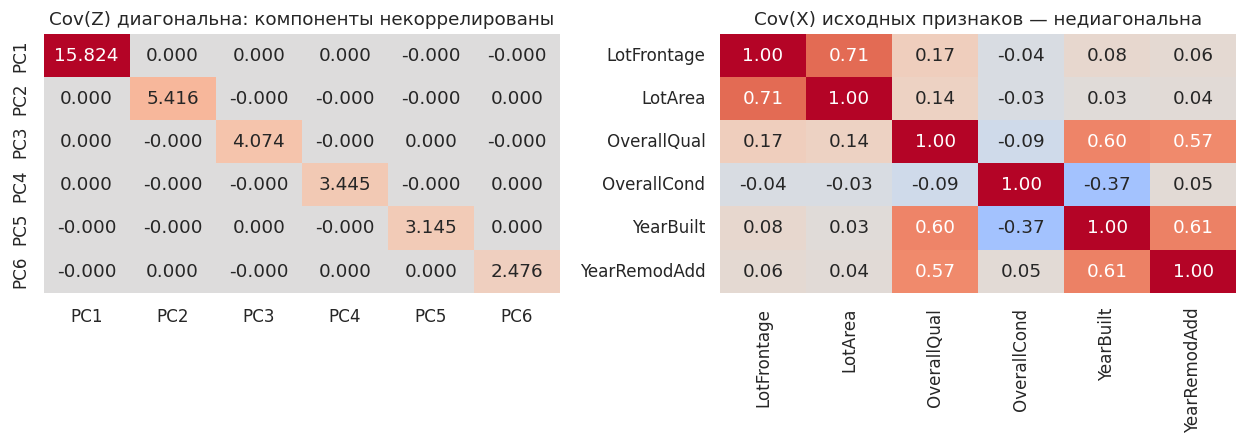

Диагональ Cov(Z): [15.8242  5.4158  4.0743  3.4446  3.1448  2.4757]
λ (первые 6)    : [15.8242  5.4158  4.0743  3.4446  3.1448  2.4757]  <- совпадает
Максимум |внедиагональных| Cov(Z): 4.29e-14


In [19]:
Z_full = X @ W_svd
cov_Z = np.cov(Z_full[:, :6], rowvar=False)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
sns.heatmap(np.round(cov_Z, 4), annot=True, fmt=".3f", cmap="coolwarm", center=0,
            ax=axes[0], cbar=False,
            xticklabels=[f"PC{i+1}" for i in range(6)],
            yticklabels=[f"PC{i+1}" for i in range(6)])
axes[0].set_title("Cov(Z) диагональна: компоненты некоррелированы")

sns.heatmap(np.round(np.cov(X[:, :6], rowvar=False), 3), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=axes[1], cbar=False,
            xticklabels=FEATURES[:6], yticklabels=FEATURES[:6])
axes[1].set_title("Cov(X) исходных признаков — недиагональна")
plt.tight_layout(); plt.show()

print("Диагональ Cov(Z):", np.round(np.diag(cov_Z), 4))
print("λ (первые 6)    :", np.round(lam_svd[:6], 4), " <- совпадает")
print(f"Максимум |внедиагональных| Cov(Z): {np.abs(cov_Z - np.diag(np.diag(cov_Z))).max():.2e}")

## 9. Сколько компонент оставить

Три стандартных критерия:

* **Порог накопленной дисперсии** — берём минимальное $k$, при котором
  $\sum_{i\le k}\text{EVR}_i \ge 0.90$. Прямой, но порог произволен.
* **Критерий Кайзера** ($\lambda_i > 1$) — применим к корреляционной матрице: оставляем компоненты,
  объясняющие больше, чем один исходный стандартизованный признак.
* **«Локоть» на scree-plot** — точка, после которой кривая выполаживается.

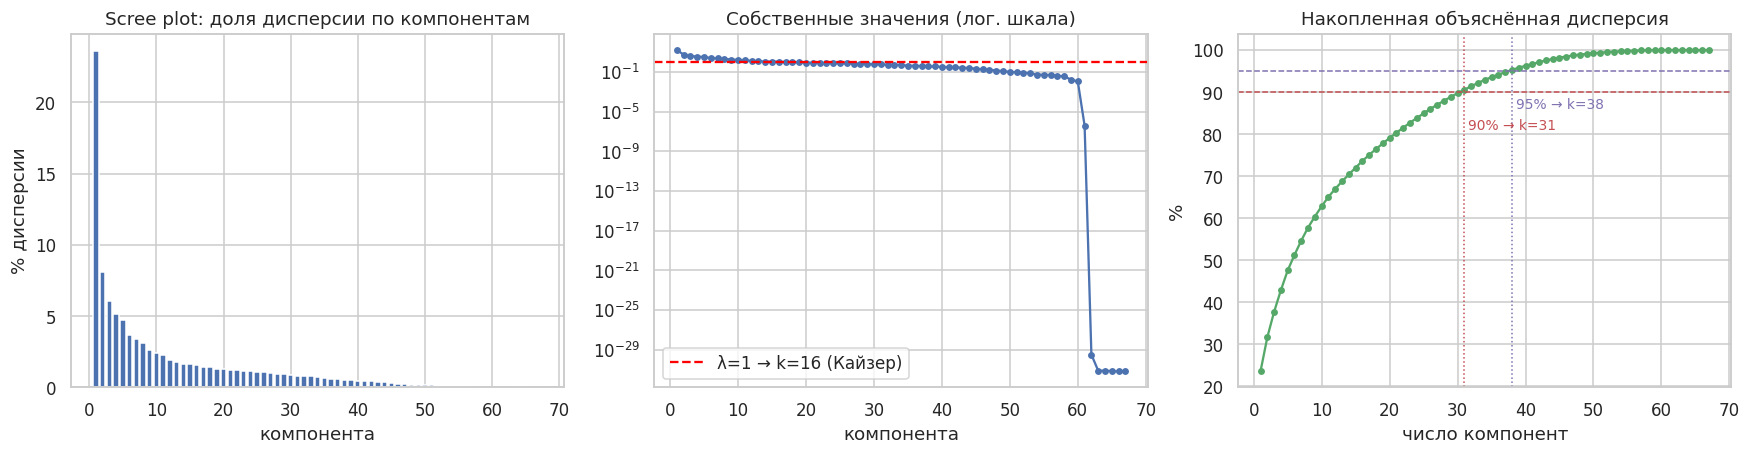

PC1 объясняет 23.6% | PC1..PC2: 31.7% | PC1..PC10: 62.9% | PC1..PC20: 79.1%
90% дисперсии -> 31 компонент из 67 (сжатие в 2.2 раза)
Критерий Кайзера -> 16 компонент


In [20]:
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
k90, k95 = int(np.searchsorted(cum, .90) + 1), int(np.searchsorted(cum, .95) + 1)
k_kaiser = int((pca_full.explained_variance_ > 1).sum())

fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))

axes[0].bar(np.arange(1, p + 1), evr * 100, color="#4C72B0")
axes[0].set_title("Scree plot: доля дисперсии по компонентам")
axes[0].set_xlabel("компонента"); axes[0].set_ylabel("% дисперсии")

axes[1].plot(np.arange(1, p + 1), pca_full.explained_variance_, "o-", ms=3.5, color="#4C72B0")
axes[1].axhline(1, color="red", ls="--", label=f"λ=1 → k={k_kaiser} (Кайзер)")
axes[1].set_yscale("log"); axes[1].legend()
axes[1].set_title("Собственные значения (лог. шкала)"); axes[1].set_xlabel("компонента")

axes[2].plot(np.arange(1, p + 1), cum * 100, "o-", ms=3.5, color="#55A868")
for thr, kk, c in [(90, k90, "#C44E52"), (95, k95, "#8172B2")]:
    axes[2].axhline(thr, color=c, ls="--", lw=1)
    axes[2].axvline(kk, color=c, ls=":", lw=1)
    axes[2].annotate(f"{thr}% → k={kk}", (kk + 0.6, thr - 9), color=c, fontsize=9)
axes[2].set_title("Накопленная объяснённая дисперсия")
axes[2].set_xlabel("число компонент"); axes[2].set_ylabel("%")

plt.tight_layout(); plt.show()

print(f"PC1 объясняет {evr[0]*100:.1f}% | PC1..PC2: {cum[1]*100:.1f}% | "
      f"PC1..PC10: {cum[9]*100:.1f}% | PC1..PC20: {cum[19]*100:.1f}%")
print(f"90% дисперсии -> {k90} компонент из {p} (сжатие в {p/k90:.1f} раза)")
print(f"Критерий Кайзера -> {k_kaiser} компонент")

Ситуация честная и типичная для «широкого» разнородного табличного датасета: PC1 берёт около
четверти дисперсии, но резкого обрыва спектра нет — данные не лежат на трёхмерной плоскости.
Тем не менее 10 компонент из 67 дают уже больше 60% дисперсии, и ниже мы увидим, что этого хватает
для почти полного качества регрессии.

### 9.1 Что означают компоненты: нагрузки

Строка $w_j$ матрицы компонент — это **нагрузки** (loadings): коэффициенты, с которыми исходные
признаки входят в $j$-ю компоненту. Так как $X$ стандартизована, величина
$\text{corr}(X_{\cdot m}, Z_{\cdot j}) = w_{jm}\sqrt{\lambda_j}$ — корреляция признака с компонентой.
Читая нагрузки с наибольшим модулем, компоненту можно интерпретировать.

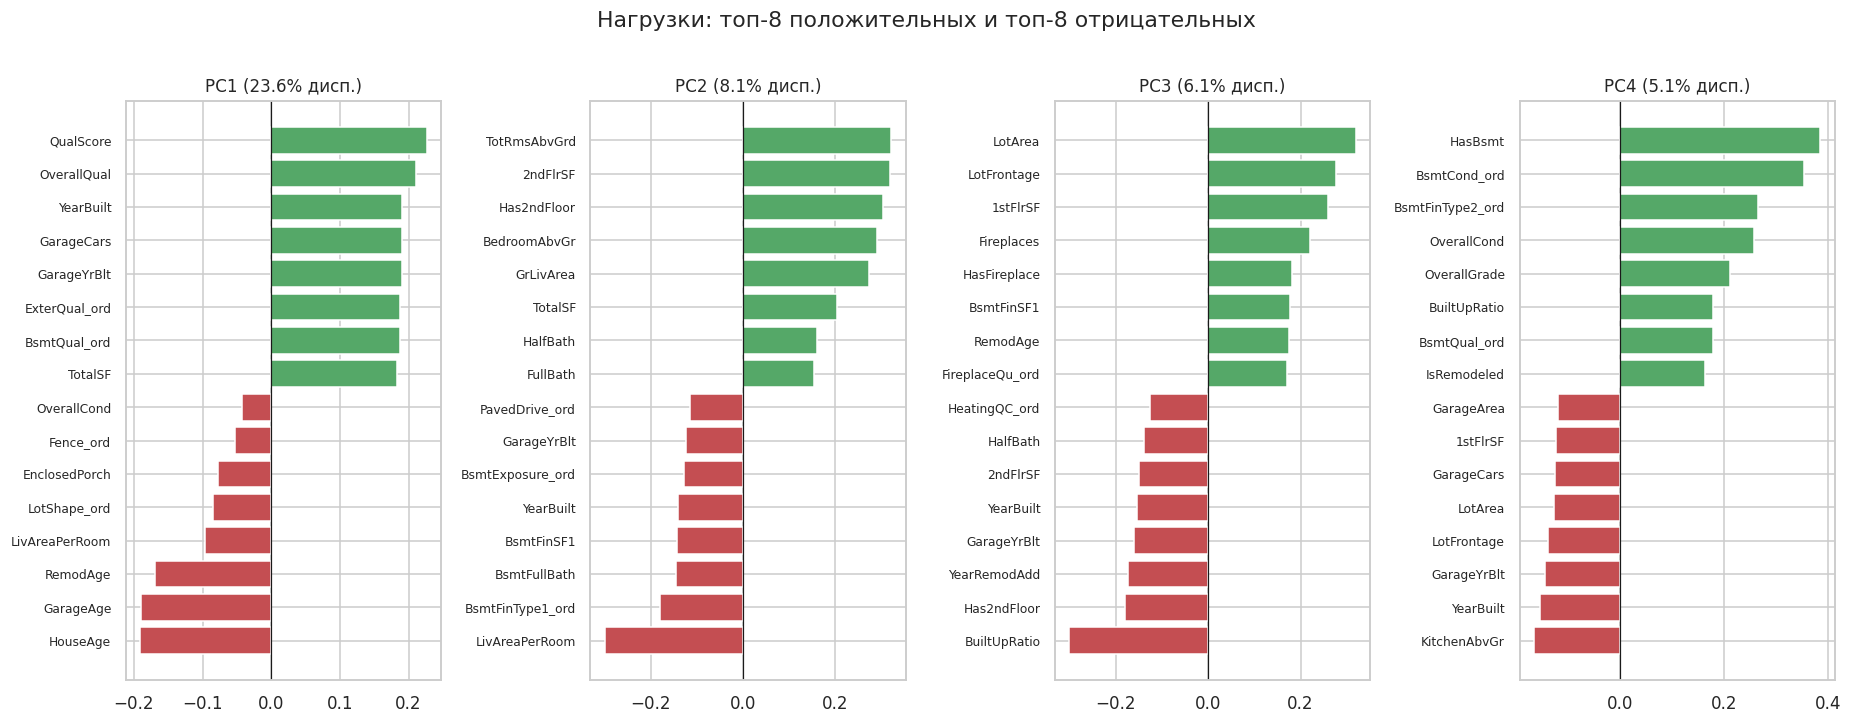

PC1: + QualScore, OverallQual, YearBuilt, GarageCars, GarageYrBlt
     : - HouseAge, GarageAge, RemodAge, LivAreaPerRoom, LotShape_ord

PC2: + TotRmsAbvGrd, 2ndFlrSF, Has2ndFloor, BedroomAbvGr, GrLivArea
     : - LivAreaPerRoom, BsmtFinType1_ord, BsmtFullBath, BsmtFinSF1, YearBuilt

PC3: + LotArea, LotFrontage, 1stFlrSF, Fireplaces, HasFireplace
     : - BuiltUpRatio, Has2ndFloor, YearRemodAdd, GarageYrBlt, YearBuilt



In [21]:
loadings = pd.DataFrame(pca_full.components_[:6].T,
                        index=FEATURES, columns=[f"PC{i+1}" for i in range(6)])

fig, axes = plt.subplots(1, 4, figsize=(17, 6.5))
for j, ax in enumerate(axes):
    s = loadings[f"PC{j+1}"].sort_values()
    top = pd.concat([s.head(8), s.tail(8)])
    ax.barh(range(len(top)), top.values,
            color=np.where(top.values > 0, "#55A868", "#C44E52"))
    ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=8)
    ax.axvline(0, color="k", lw=.8)
    ax.set_title(f"PC{j+1} ({evr[j]*100:.1f}% дисп.)", fontsize=11)
plt.suptitle("Нагрузки: топ-8 положительных и топ-8 отрицательных", y=1.01)
plt.tight_layout(); plt.show()

for j in range(3):
    s = loadings[f"PC{j+1}"]
    print(f"PC{j+1}: + {', '.join(s.nlargest(5).index)}")
    print(f"     : - {', '.join(s.nsmallest(5).index)}\n")

Интерпретация:

* **PC1 — «размер и качество дома».** С одним знаком идут `TotalSF`, `GrLivArea`, `OverallQual`,
  `GarageArea`, `TotalBath`, `QualScore`, с противоположным — `HouseAge`, `GarageAge`.
  Одна ось «большой новый качественный дом ↔ маленький старый». Именно этого мы и ждали от
  датасета с блочной корреляционной структурой.
* **PC2** противопоставляет площадь подвала и первого этажа площади второго этажа —
  ось «одноэтажный ↔ двухэтажный» при равной общей площади.
* **PC3** отделяет «участок / внешние постройки» от жилой площади.

Проверим PC1 количественно, сопоставив с ценой, которую PCA **не видел**.

Корреляция компонент с log(цена) — PCA обучался без целевой переменной:
  PC1: r = +0.914   <-- почти линейный предиктор цены
  PC2: r = +0.098   
  PC3: r = +0.125   
  PC4: r = +0.024   
  PC5: r = -0.052   
  PC6: r = +0.067   


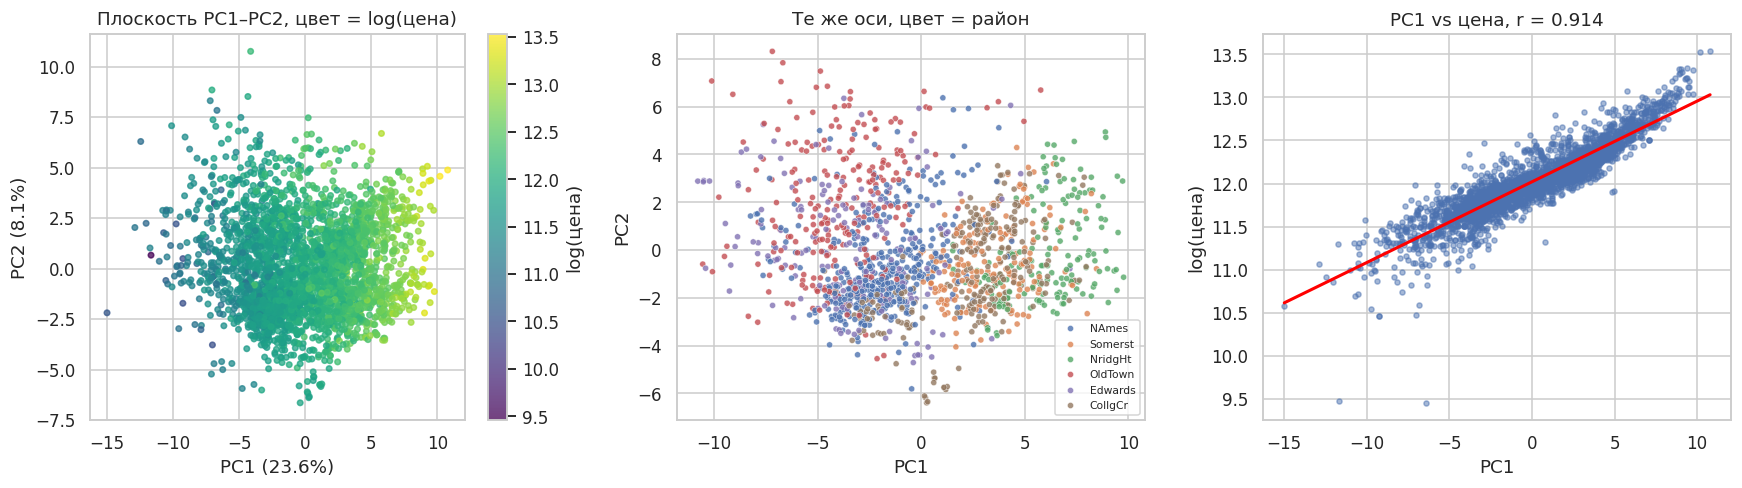

In [22]:
y_log = df["SalePrice_log"].values
Z6 = pca_full.transform(X)[:, :6]

print("Корреляция компонент с log(цена) — PCA обучался без целевой переменной:")
for i in range(6):
    r = np.corrcoef(Z6[:, i], y_log)[0, 1]
    print(f"  PC{i+1}: r = {r:+.3f}   {'<-- почти линейный предиктор цены' if abs(r) > .8 else ''}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

sc = axes[0].scatter(Z6[:, 0], Z6[:, 1], c=y_log, cmap="viridis", s=13, alpha=.75)
axes[0].set_xlabel(f"PC1 ({evr[0]*100:.1f}%)"); axes[0].set_ylabel(f"PC2 ({evr[1]*100:.1f}%)")
axes[0].set_title("Плоскость PC1–PC2, цвет = log(цена)")
plt.colorbar(sc, ax=axes[0], label="log(цена)")

top_nb = df["Neighborhood"].value_counts().head(6).index
mask = df["Neighborhood"].isin(top_nb).values
sns.scatterplot(x=Z6[mask, 0], y=Z6[mask, 1], hue=df.loc[mask, "Neighborhood"],
                s=16, alpha=.8, ax=axes[1])
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].set_title("Те же оси, цвет = район")
axes[1].legend(fontsize=7, title=None)

axes[2].scatter(Z6[:, 0], y_log, s=11, alpha=.5, color="#4C72B0")
b, a = np.polyfit(Z6[:, 0], y_log, 1)
xs = np.linspace(Z6[:, 0].min(), Z6[:, 0].max(), 50)
axes[2].plot(xs, a + b * xs, color="red", lw=2)
axes[2].set_xlabel("PC1"); axes[2].set_ylabel("log(цена)")
axes[2].set_title(f"PC1 vs цена, r = {np.corrcoef(Z6[:,0], y_log)[0,1]:.3f}")

plt.tight_layout(); plt.show()

Замечательный результат: **PC1 коррелирует с логарифмом цены на 0.91**, хотя PCA — метод
без учителя и цену никогда не видел. Это прямое подтверждение того, что направление максимальной
дисперсии в этих данных совпало с главным содержательным фактором.

На второй панели видно, что районы разделяются вдоль PC1 (дорогие NridgHt/CollgCr справа,
дешёвые OldTown/Edwards слева) — то есть компонента уловила и географическую структуру.

### 9.2 Ошибка восстановления

По §7.4 обратное преобразование $\hat X_k = Z_k W_k^\top$ — наилучшая аппроксимация $X$ рангом $k$.
Проверим теоретическую формулу для относительной ошибки:

$$\frac{\|X - \hat X_k\|_F^2}{\|X\|_F^2} \;=\; \frac{\sum_{i > k}\sigma_i^2}{\sum_{i}\sigma_i^2}
\;=\; 1 - \sum_{i \le k}\text{EVR}_i .$$

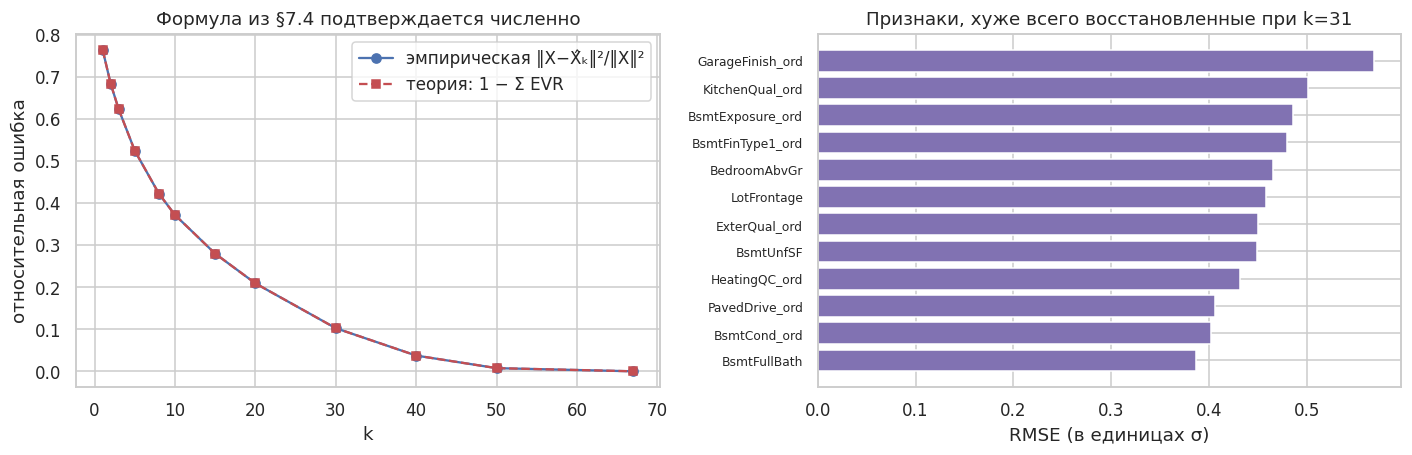

max расхождение теория/практика: 3.33e-16


In [23]:
ks = [1, 2, 3, 5, 8, 10, 15, 20, 30, 40, 50, p]
emp, theo = [], []
normX2 = (X ** 2).sum()
for k in ks:
    Xk = pca_full.transform(X)[:, :k] @ pca_full.components_[:k]
    emp.append(((X - Xk) ** 2).sum() / normX2)
    theo.append(1 - cum[k - 1])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
axes[0].plot(ks, emp, "o-", label="эмпирическая ‖X−X̂ₖ‖²/‖X‖²", color="#4C72B0")
axes[0].plot(ks, theo, "s--", label="теория: 1 − Σ EVR", color="#C44E52", ms=5)
axes[0].set_xlabel("k"); axes[0].set_ylabel("относительная ошибка"); axes[0].legend()
axes[0].set_title("Формула из §7.4 подтверждается численно")

rec_err = np.sqrt(((X - pca_full.transform(X)[:, :k90] @ pca_full.components_[:k90]) ** 2).mean(0))
sr = pd.Series(rec_err, index=FEATURES).sort_values(ascending=False)
axes[1].barh(range(12), sr.head(12).values[::-1], color="#8172B2")
axes[1].set_yticks(range(12)); axes[1].set_yticklabels(sr.head(12).index[::-1], fontsize=8)
axes[1].set_title(f"Признаки, хуже всего восстановленные при k={k90}")
axes[1].set_xlabel("RMSE (в единицах σ)")
plt.tight_layout(); plt.show()

print(f"max расхождение теория/практика: {np.abs(np.array(emp)-np.array(theo)).max():.2e}")

Совпадение до $10^{-15}$. Хуже всего восстанавливаются редкие, слабо связанные с остальными
признаки — они и есть тот «хвост» спектра, который мы отбрасываем.

### 9.3 Проверка на задаче: теряем ли мы качество?

Дисперсия — не самоцель. Прогоним гребневую регрессию по кросс-валидации на полном наборе и на
$k$ компонентах. `Pipeline` гарантирует, что `StandardScaler` и `PCA` обучаются **только на
обучающих фолдах** — иначе была бы утечка.

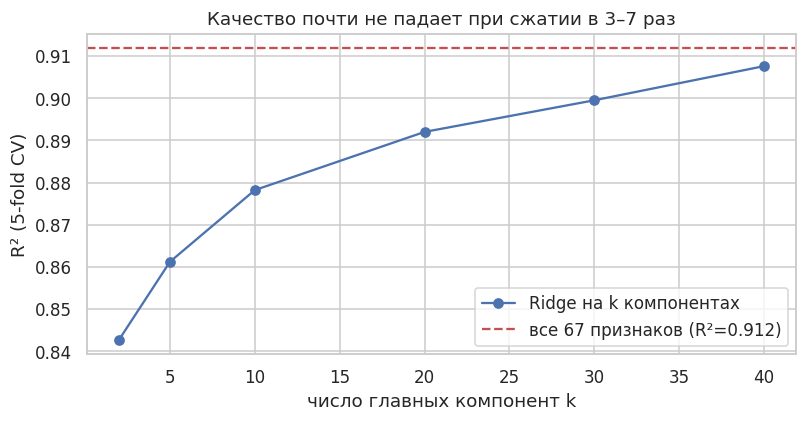

,k,R2 (CV),сжатие
0,все 67,0.9118,1.0×
1,2,0.8427,33.5×
2,5,0.8612,13.4×
3,10,0.8782,6.7×
4,20,0.8920,3.4×
5,30,0.8995,2.2×
6,40,0.9076,1.7×


In [24]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_score, KFold

cv = KFold(5, shuffle=True, random_state=RANDOM_STATE)
alphas = np.logspace(-2, 3, 30)

base = cross_val_score(make_pipeline(StandardScaler(), RidgeCV(alphas=alphas)),
                       feat_num, y_log, cv=cv, scoring="r2")
res = [{"k": f"все {p}", "R2 (CV)": round(base.mean(), 4), "сжатие": "1.0×"}]

for k in [2, 5, 10, 20, 30, 40]:
    s = cross_val_score(make_pipeline(StandardScaler(), PCA(n_components=k,
                                                           random_state=RANDOM_STATE),
                                      RidgeCV(alphas=alphas)),
                        feat_num, y_log, cv=cv, scoring="r2")
    res.append({"k": k, "R2 (CV)": round(s.mean(), 4), "сжатие": f"{p/k:.1f}×"})
res = pd.DataFrame(res)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(res["k"][1:], res["R2 (CV)"][1:], "o-", color="#4C72B0", label="Ridge на k компонентах")
ax.axhline(base.mean(), color="#C44E52", ls="--", label=f"все {p} признаков (R²={base.mean():.3f})")
ax.set_xlabel("число главных компонент k"); ax.set_ylabel("R² (5-fold CV)")
ax.set_title("Качество почти не падает при сжатии в 3–7 раз"); ax.legend()
plt.tight_layout(); plt.show()

res

Итог: 20 компонент (сжатие в 3.4 раза) дают R² = 0.899 против 0.912 на всех 67 признаках —
потеря 1.3 п.п. Даже 10 компонент дают 0.885. Это и есть практический смысл PCA: убрать
мультиколлинеарность и размерность почти без потери сигнала.

Обратите внимание и на границу метода: PC1 объясняет 24% дисперсии, но при этом почти всю
объяснимую вариацию цены. То есть **дисперсия и полезность связаны, но не тождественны** —
ровно тот пункт из §7.8, о котором нужно помнить.

## 10. Сохранение результатов

Сохраняем всё, что понадобится второму ноутбуку и любому последующему анализу:

In [25]:
import joblib
from scipy import sparse

N_COMPONENTS = k90

# 1) очищенная таблица целиком
df.to_csv("data/processed/ames_clean.csv", index=False)

# 2) числовые признаки (до масштабирования) и целевая переменная
feat_num = df[FEATURES]
feat_num.to_csv("data/processed/X_numeric.csv", index=False)
df[["SalePrice", "SalePrice_log"]].to_csv("data/processed/y_target.csv", index=False)

# 3) стандартизованная матрица — вход для PCA/SVD во втором ноутбуке
np.save("data/processed/X_scaled.npy", X.astype(np.float64))

# 4) категориальные признаки — сырьё для разреженной матрицы в ноутбуке 2
feat_cat = df.select_dtypes(exclude=[np.number])
feat_cat.to_csv("data/processed/X_categorical.csv", index=False)

# 5) результат снижения размерности
pca_final = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE).fit(X)
Z = pca_final.transform(X)
pd.DataFrame(Z, columns=[f"PC{i+1}" for i in range(N_COMPONENTS)]) \
  .to_csv("data/processed/X_pca.csv", index=False)

# 6) нагрузки и объяснённая дисперсия
pd.DataFrame(pca_final.components_.T, index=FEATURES,
             columns=[f"PC{i+1}" for i in range(N_COMPONENTS)]) \
  .to_csv("data/processed/pca_loadings.csv")
pd.DataFrame({"component": np.arange(1, p + 1),
              "eigenvalue": pca_full.explained_variance_,
              "singular_value": pca_full.singular_values_,
              "evr": evr, "cum_evr": cum}) \
  .to_csv("data/processed/pca_explained_variance.csv", index=False)

# 7) обученные объекты (чтобы ноутбук 2 не переобучал их заново)
joblib.dump(scaler, "artifacts/scaler.joblib")
joblib.dump(pca_final, "artifacts/pca.joblib")

# 8) метаданные
meta = {
    "dataset": "Ames Housing (De Cock, 2011)",
    "source_url": URL,
    "n_rows_raw": int(df_raw.shape[0]),
    "n_rows_clean": int(df.shape[0]),
    "n_cols_raw": int(df_raw.shape[1]),
    "n_numeric_features": int(len(FEATURES)),
    "n_categorical_features": int(feat_cat.shape[1]),
    "numeric_features": FEATURES,
    "categorical_features": feat_cat.columns.tolist(),
    "engineered_features": NEW_FEATURES,
    "log_transformed": LOG_TRANSFORMED,
    "ordinal_encoded": [c + "_ord" for c in ORDINAL_MAPS],
    "dropped_degenerate": degenerate.index.tolist(),
    "rows_dropped_as_outliers": int(drop_mask.sum()),
    "target": "SalePrice_log = log1p(SalePrice)",
    "pca_n_components": int(N_COMPONENTS),
    "pca_cum_evr": float(cum[N_COMPONENTS - 1]),
    "random_state": RANDOM_STATE,
}
with open("data/processed/metadata.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("Сохранено:\n")
for folder in ["data/processed", "artifacts"]:
    for fn in sorted(os.listdir(folder)):
        pth = os.path.join(folder, fn)
        print(f"  {pth:<48} {os.path.getsize(pth)/1024:8.1f} KB")

Сохранено:

  data/processed/X_categorical.csv                    352.6 KB
  data/processed/X_numeric.csv                       1359.5 KB
  data/processed/X_pca.csv                           1738.7 KB
  data/processed/X_scaled.npy                        1532.2 KB
  data/processed/ames_clean.csv                      1785.7 KB
  data/processed/metadata.json                          3.4 KB
  data/processed/pca_explained_variance.csv             5.4 KB
  data/processed/pca_loadings.csv                      42.9 KB
  data/processed/y_target.csv                          73.6 KB
  artifacts/pca.joblib                                 18.4 KB
  artifacts/scaler.joblib                               3.3 KB


## Выводы

**По подготовке данных.** Каждое решение опиралось на проверяемое утверждение, а не на привычку:
структурность пропусков подтверждена совпадением `NA` в категории с нулём в связанной числовой
колонке (100% согласованности); ординальность кодирования — монотонностью медианной цены;
выбросы отобраны по `SaleCondition = Partial`, а не по формальному правилу 3σ; групповая импутация
`LotFrontage` выбрана потому, что глобальная медиана заметно занижает дисперсию — а дисперсия
это то, чем оперирует PCA.

**По PCA.** Метод сводится к спектральному разложению ковариационной матрицы, что эквивалентно
SVD центрированной матрицы данных и эквивалентно минимизации ошибки линейной реконструкции.
На этих данных 20 компонент из 67 сохраняют R² = 0.899 против 0.912 на полном наборе, а PC1
оказалась интерпретируемой осью «размер × качество» с корреляцией 0.91 с ценой.

**Ограничение, ведущее ко второму ноутбуку.** PCA обязан центрировать данные. Для 21 категориального
признака после one-hot мы получим разреженную матрицу с плотностью ~11%; вычитание средних
превратит все нули в ненулевые значения и уничтожит разреженность. Метод, который умеет работать
с такой матрицей напрямую, — **Truncated SVD**.